In [52]:
what_we_are_covering = {
    1: "data(prepare and load)",
    2: "build a model",
    3: "fitting the model to training data",
    4: "making predictions and evaluate the model (inference)",
    5: "saving and loading a model",
    6: "putting it all together"
}

In [53]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

### Data Preparing and loading

Data Workflow:

<div align="center"><img src="image.png" width="700"></div>


In [54]:
# create known parameters

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start=start, step=step, end=end).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [55]:
# Split data into training and test data 

In [56]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]

X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [97]:
def plot_predictions(
    train_data=X_train, 
    train_labels=y_train, 
    test_data=X_test, 
    test_labels=y_test, 
    predictions=None
):
    plt.figure(figsize=(10, 6))

    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label='Prediction data')
    
    plt.legend(prop={
        'size': 14
    })
    plt.grid()




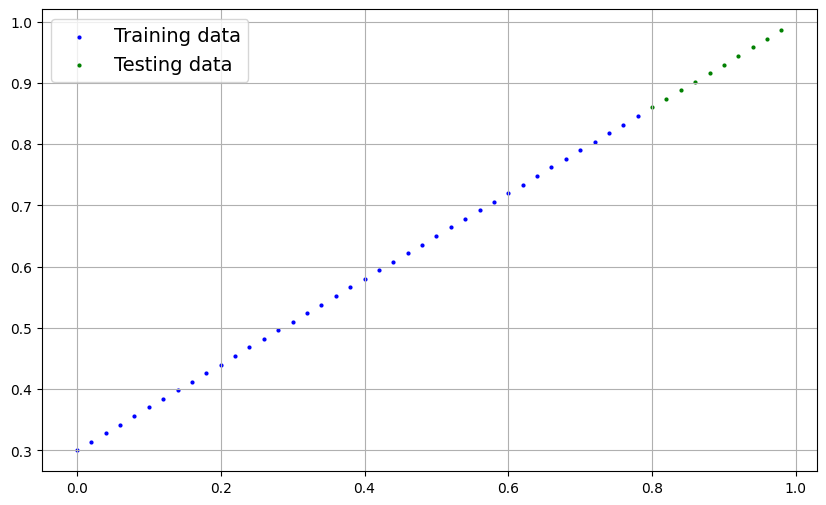

In [58]:
plot_predictions()

### Building First PyTorch Model: Linear Regression

In [59]:
# Creating linear regression model class

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # parameters or layers inside the constructor 
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    # Computation shall be carried on
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias


### PyTorch model building essentials

* torch.nn - contains all of the buildings for computational graphs(neural network)
* torch.nn.Parameter - what parameters should our model try and learn
* torch.nn.Module - the base class for all neural network modules, should overwrite the **forward** method
* torch.optim - this is where PyTorch's optimizators live, the help with gradient descent and more 
* torch.utils.data.Dataset - Represents a key-value pairs between parameters(features) = value and labels(targets) = key
* torch.utils.data.DataLoader - creates the Python iterable over a torch DataSet

### Checking the contents of our PyTorch model

In [60]:
# Create a random Seed

torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [61]:
# List named parameters 

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making predictions with torch.inference_mode()

In [62]:
# Making Predictions 

with torch.inference_mode():
    y_preds = model_0(X_train)

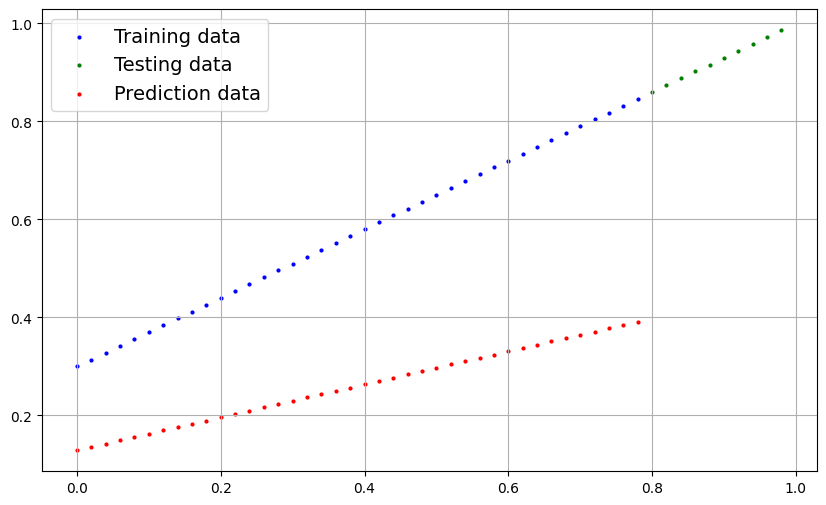

In [63]:
plot_predictions(predictions=y_preds)

### Train model

* Tuning by keeping the track of **Loss(Cost) Function** - how our model's predictions are lacking from the actual values, lower is better
* **Optimizer** - Taking into account the loss function values optimizes the Weight and Bias 


In [64]:
# Setting up the Loss Function 

loss_fn = nn.L1Loss()

# Set up Optimizer(stochastic gradient descent)

optimizer_fn = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.001
)


### Training Loop with PyTorch

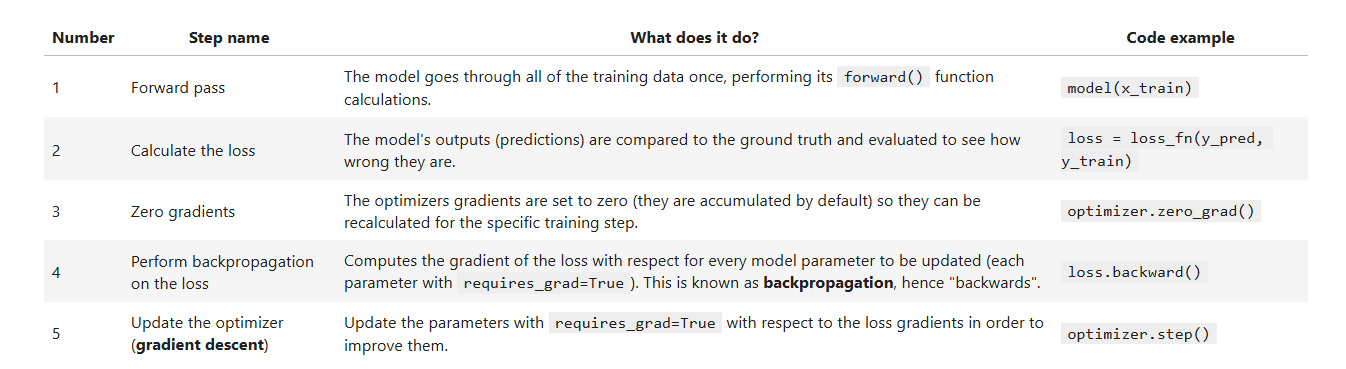

In [65]:
import torch

# Number of epochs
epochs = 2000

# Tracking lists
epoch_cnt_train = []
loss_track_train = []

epoch_cnt_test = []
loss_track_test = []

for epoch in range(epochs):

    # ======================
    # TRAINING
    # ======================
    model_0.train()

    # Forward pass
    y_pred = model_0(X_train)

    # Compute loss
    train_loss = loss_fn(y_pred, y_train)

    # Zero gradients
    optimizer_fn.zero_grad()

    # Backpropagation
    train_loss.backward()

    # Update weights
    optimizer_fn.step()

    # ======================
    # TESTING
    # ======================
    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)

    # ======================
    # LOGGING
    # ======================
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch} | "
            f"Train Loss: {train_loss.item():.5f} | "
            f"Test Loss: {test_loss.item():.5f}"
        )

    if epoch % 25 == 0:
        epoch_cnt_train.append(epoch)
        loss_track_train.append(train_loss.item())

        epoch_cnt_test.append(epoch)
        loss_track_test.append(test_loss.item())


Epoch 0 | Train Loss: 0.31288 | Test Loss: 0.49319
Epoch 10 | Train Loss: 0.30136 | Test Loss: 0.47972
Epoch 20 | Train Loss: 0.28984 | Test Loss: 0.46625
Epoch 30 | Train Loss: 0.27832 | Test Loss: 0.45278
Epoch 40 | Train Loss: 0.26680 | Test Loss: 0.43931
Epoch 50 | Train Loss: 0.25528 | Test Loss: 0.42583
Epoch 60 | Train Loss: 0.24376 | Test Loss: 0.41236
Epoch 70 | Train Loss: 0.23223 | Test Loss: 0.39889
Epoch 80 | Train Loss: 0.22071 | Test Loss: 0.38542
Epoch 90 | Train Loss: 0.20919 | Test Loss: 0.37195
Epoch 100 | Train Loss: 0.19767 | Test Loss: 0.35848
Epoch 110 | Train Loss: 0.18615 | Test Loss: 0.34501
Epoch 120 | Train Loss: 0.17463 | Test Loss: 0.33154
Epoch 130 | Train Loss: 0.16311 | Test Loss: 0.31807
Epoch 140 | Train Loss: 0.15159 | Test Loss: 0.30460
Epoch 150 | Train Loss: 0.14007 | Test Loss: 0.29113
Epoch 160 | Train Loss: 0.12855 | Test Loss: 0.27765
Epoch 170 | Train Loss: 0.11703 | Test Loss: 0.26418
Epoch 180 | Train Loss: 0.10654 | Test Loss: 0.25132
Epoc

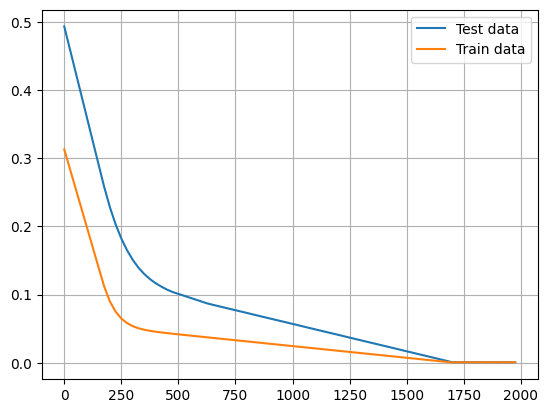

In [66]:
plt.plot(epoch_cnt_test, loss_track_test, label='Test data')
plt.plot(epoch_cnt_train, loss_track_train, label='Train data')
plt.legend()
plt.grid()

In [67]:
with torch.inference_mode():
    y_preds_new = model_0(X_train)

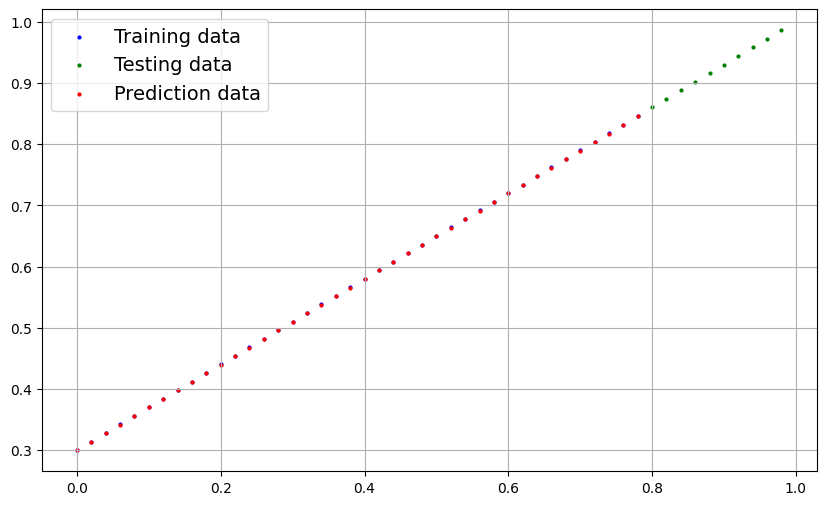

In [68]:
plot_predictions(predictions=y_preds_new)

In [69]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6994])), ('bias', tensor([0.2998]))])

### Save a model in PyTorch

1. `torch.save()` - Save the model as a python's pickle object
2. `torch.load()` - Load that saved file
3. `torch.nn.Module.load_state_dict()` - Load the saved state dict smth like: **{weight:0.23, bias:0.343}**

In [70]:
from pathlib import Path

# Path Creation
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(exist_ok=True, parents=True)

# Saving
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
model_save_path = MODEL_PATH / MODEL_NAME

torch.save(obj=model_0, f=model_save_path)

In [71]:
model = torch.load(model_save_path)

C:\Users\DILSHOD\AppData\Local\Temp\ipykernel_32220\2844726666.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_save_path)


In [72]:
model.state_dict()

OrderedDict([('weights', tensor([0.6994])), ('bias', tensor([0.2998]))])

### Putting Everything Together

In [73]:
import torch
from torch import nn
import matplotlib.pyplot as plt


In [74]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
print("using Device", device)

using Device cuda


### Creating Dummy data

In [75]:
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

X = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)
y = weight * X + bias


In [76]:
# Split data

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


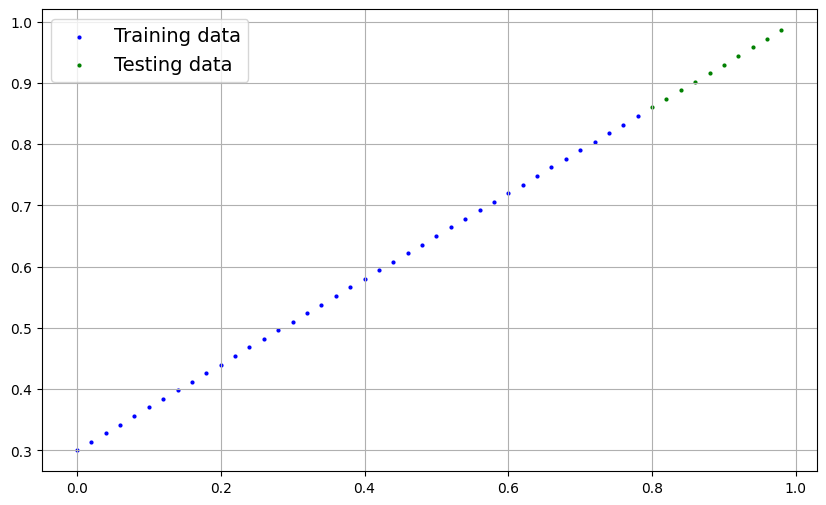

In [77]:
plot_predictions(X_train, y_train, X_test, y_test)

In [78]:
# Create a model 

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Use nn.Linear() for creating the model parameters 
        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(X)


# Set the manual seed

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [87]:
model_1.to(device)
# Set the model to use the target device
next(model_1.parameters()).device

device(type='cuda', index=0)

### Training Code 

* Loss function
* Optimizer
* Training Loop
* Testing Loop

In [88]:
# Loss Function 

loss_function = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)


In [89]:
torch.manual_seed(42)

epochs = 200

# Put Data on the target device(Device Agnostic Code for data)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):

    model_1.train()

    # 1. Forward Pass
    y_pred = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_function(y_pred, y_train)

    # 3. Optimize zero gradient
    optimizer.zero_grad()

    # 4. Backward propagation
    loss.backward()

    # 5. Optimizer Step
    optimizer.step()

    ### Testing 

    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_function(test_pred, y_test)

    if epoch % 20 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Params: {model_1.state_dict()}")
        print(f"Epoch: {epoch} | Loss: {test_loss} | Params: {model_1.state_dict()}")

Epoch: 0 | Loss: 0.5551779866218567 | Params: OrderedDict([('linear_layer.weight', tensor([[0.7606]], device='cuda:0')), ('linear_layer.bias', tensor([0.8200], device='cuda:0'))])
Epoch: 0 | Loss: 0.5739762187004089 | Params: OrderedDict([('linear_layer.weight', tensor([[0.7606]], device='cuda:0')), ('linear_layer.bias', tensor([0.8200], device='cuda:0'))])
Epoch: 20 | Loss: 0.3247582018375397 | Params: OrderedDict([('linear_layer.weight', tensor([[0.6826]], device='cuda:0')), ('linear_layer.bias', tensor([0.6200], device='cuda:0'))])
Epoch: 20 | Loss: 0.30455657839775085 | Params: OrderedDict([('linear_layer.weight', tensor([[0.6826]], device='cuda:0')), ('linear_layer.bias', tensor([0.6200], device='cuda:0'))])
Epoch: 40 | Loss: 0.09433845430612564 | Params: OrderedDict([('linear_layer.weight', tensor([[0.6046]], device='cuda:0')), ('linear_layer.bias', tensor([0.4200], device='cuda:0'))])
Epoch: 40 | Loss: 0.03513690456748009 | Params: OrderedDict([('linear_layer.weight', tensor([[0

In [98]:
model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

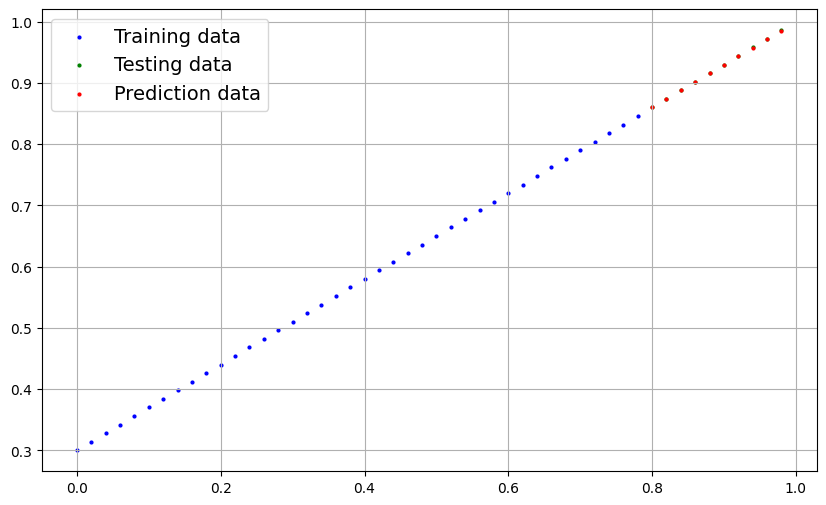

In [99]:
plot_predictions(test_data=X_test.cpu(), test_labels=y_test.cpu(), train_data=X_train.cpu(), train_labels=y_train.cpu(), predictions=y_preds.cpu())

In [117]:
from torch.utils.tensorboard import SummaryWriter

# Writer outputs to ./runs/ directory by default
writer = SummaryWriter()

# In your training loop, log scalar values
for step in range(epochs):
    writer.add_scalar('Loss/train', loss, step)

# Ensure all logs are written to disk
writer.flush()
writer.close()


### Taylor Series in ML 

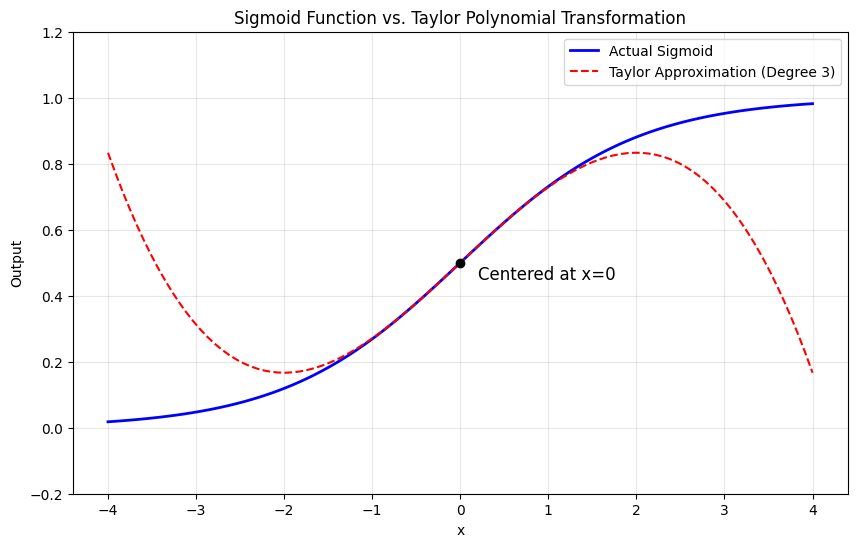

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the actual Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 2. Define the 3rd-degree Taylor Polynomial centered at 0
# P(x) = 1/2 + 1/4x - 1/48x^3
def taylor_sigmoid(x):
    return 0.5 + 0.25*x - (1/48)*(x**3)

# Generate data points
x = np.linspace(-4, 4, 100)
y_actual = sigmoid(x)
y_approx = taylor_sigmoid(x)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y_actual, label='Actual Sigmoid', color='blue', linewidth=2)
plt.plot(x, y_approx, label='Taylor Approximation (Degree 3)', color='red', linestyle='--')

# Highlight the center point (where the approximation is most accurate)
plt.scatter([0], [0.5], color='black', zorder=8)
plt.text(0.2, 0.45, 'Centered at x=0', fontsize=12)

plt.title('Sigmoid Function vs. Taylor Polynomial Transformation')
plt.xlabel('x')
plt.ylabel('Output')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.2, 1.2)
plt.show()
